In [2]:
import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

## EJERCICIO CLASE TEORICA 22/05

In [9]:
datos = pd.read_csv("datasets/Parte_2/advertising.csv")
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### Ejercicio 1
Calcula la matriz de correlaciones lineales entre todas las variables del dataset. Que predictories parecen estar mas asociados con sales?

In [4]:
matriz_corr = datos.corr().round(2)
matriz_corr

,TV,Radio,Newspaper,Sales
TV,1.00,0.05,0.06,0.90
Radio,0.05,1.00,0.35,0.35
Newspaper,0.06,0.35,1.00,0.16
Sales,0.90,0.35,0.16,1.00


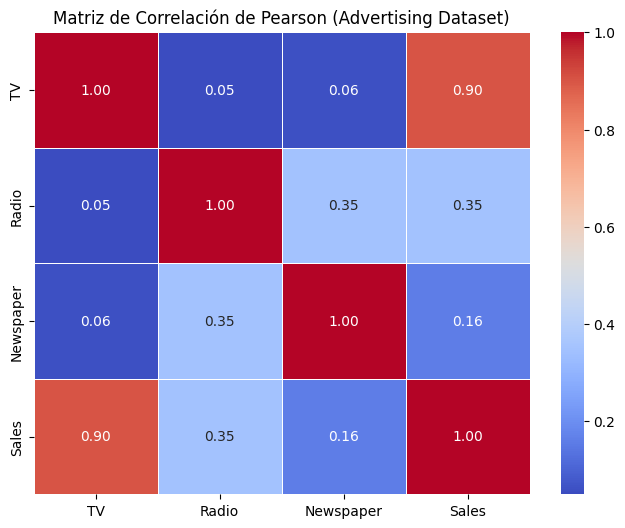

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, 
            annot=True,       # Muestra el número dentro de cada celda
            cmap='coolwarm',  # Escala de colores (Rojo=Positivo, Azul=Negativo)
            fmt=".2f",        # Limita a 2 decimales
            linewidths=0.5)   # Agrega una pequeña línea divisoria entre celdas

plt.title('Matriz de Correlación de Pearson (Advertising Dataset)')
plt.show()

### Ejercicio 2
Ajusta un modelo de regresion lineal multiple para sales usando los tres predictores: TV, Radio, Newspaper. 
Cuales predictores son estadisticamente significativos al 5%?

In [6]:
modelo1 = smf.ols(formula= 'Sales ~ TV + Radio + Newspaper', data=datos).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        18:34:15   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

### Ejercicio 3
Reajusta el modelo eliminando el o los predictores no significativos.

In [7]:
modelo2 = smf.ols(formula= 'Sales ~ TV + Radio', data=datos).fit()  #Ajustamos Modelo Reducido
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        18:34:15   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

Usando el modelo reducido, estima las ventas esperadas para un mercado con inversion de 150 mil USD en TV, 30 mil USD en Radio y 60 mil USD en periodicos.

Prediccion:

In [8]:
# el metodo .predict necesita de un objeto de tipo df, por lo tanto armamos uno con, para cada uno los predictores, 
# el valor para el que quiero predecir la respuesta.
datos_prediccion = pd.DataFrame({'TV' : [150],
                                'Radio' : [30]})
# ponerle o no el valor para newspaper, es indistinto ya que este predictor no se encuentra en el modelo

modelo2.predict(datos_prediccion).round(2)

0    16.01
dtype: float64

"Si el local invierte 150 unidades en publicidad de TV y 30 unidades en Radio, el modelo predice que se obtendrá un total estimado de 16.01 unidades en Ventas, independientemente de lo que se decida invertir en periódicos (ya que esta variable no altera el resultado)".

-----------------------------------------------------------------------------------------------------------------------------------------------

# EJERCICIO 1

In [21]:
student_data = pd.read_csv("datasets/Parte_2/student_data.csv")
student_data = student_data.drop(columns='Unnamed: 0')
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hours_studied  245 non-null    float64
 1   exam_scores    245 non-null    float64
dtypes: float64(2)
memory usage: 4.0 KB


In [22]:
student_data.head(15)

,hours_studied,exam_scores
0,9.3,63.1
1,23.9,90.4
2,12.9,63.2
3,26.6,87.8
4,28.3,92.9
5,2.3,53.6
6,16.3,71.5
7,26.9,93.6
8,17.0,74.1
9,14.2,68.4


PUNTO 1

<Axes: xlabel='hours_studied', ylabel='exam_scores'>

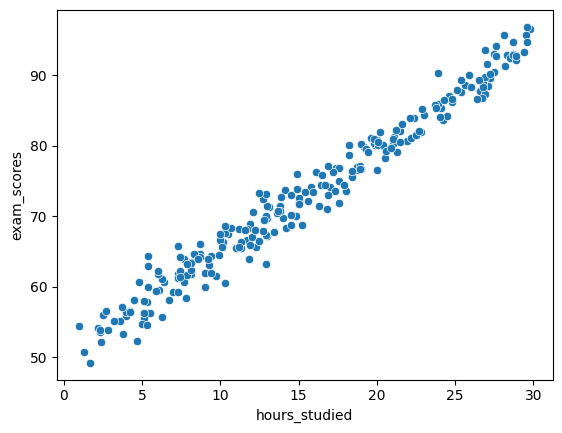

In [24]:
# Para visualizar las dos variables en cuestion vamos a realizar un scatterplot

sns.scatterplot(data=student_data, x='hours_studied', y='exam_scores')

Notamos claramente una relacion lineal fuerte entre las horas de estudio y la nota del examen final.

In [25]:
# Para corroborar lo dicho vamos a hacer una matriz de correlacion de Pearson

student_data.corr()

,hours_studied,exam_scores
hours_studied,1.000000,0.986093
exam_scores,0.986093,1.000000


En la interseccion de las variables, notamos un fuerte valor para R (coeficiente de Pearson) que nos dice que tenemos una asociacion lineal fuerte

PUNTO 2

In [27]:
modelo_estudio = smf.ols('exam_scores ~ hours_studied', data=student_data).fit()
print(modelo_estudio.summary())

                            OLS Regression Results                            
Dep. Variable:            exam_scores   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     8555.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          2.11e-191
Time:                        19:02:15   Log-Likelihood:                -512.26
No. Observations:                 245   AIC:                             1029.
Df Residuals:                     243   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        50.2541      0.278    180.576

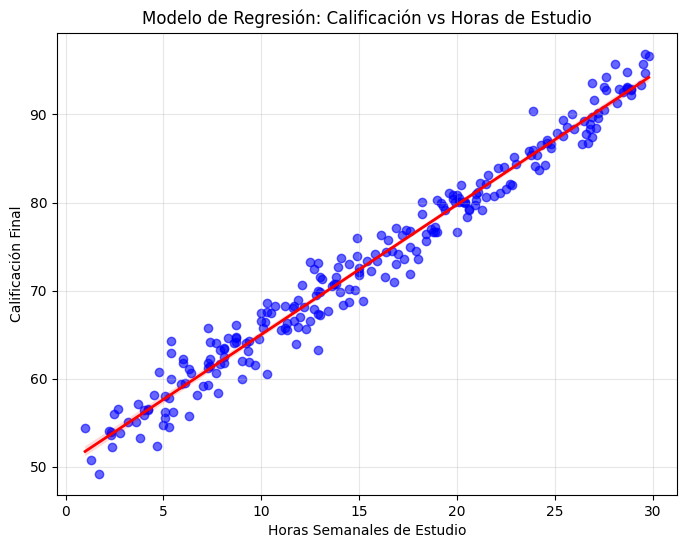

In [32]:
# --- PARTE 1: REPRESENTACIÓN GRÁFICA ---
plt.figure(figsize=(8, 6))

# Usamos regplot en lugar de scatterplot. 
# regplot dibuja los puntos (ítem 1) y automáticamente calcula y dibuja la línea de regresión.
sns.regplot(data=student_data, 
            x='hours_studied', 
            y='exam_scores', 
            scatter_kws={'color': 'blue', 'alpha': 0.6}, # Estilo de los puntos
            line_kws={'color': 'red', 'lw': 2})          # Estilo de la línea del modelo

plt.title('Modelo de Regresión: Calificación vs Horas de Estudio')
plt.xlabel('Horas Semanales de Estudio')
plt.ylabel('Calificación Final')
plt.grid(True, alpha=0.3)
plt.show()

PUNTO 3

El modelo ajustado nos queda de la siguiente manera 

    exam_scores = 50.25 + 1.48 * hours_studied

donde la constante representa la calificacion que se sacaria un estudiante si estudiara 0hs y la pendiente representa como mejoraria la

calificacion por cada hora estudiada

# EJERCICIO 2